# Notebook 05 - Model Interpretability

**Author:** Umanda Thathsarani | IT3091 Machine Learning

---

## Why Interpretability Matters

In healthcare, a black-box model that just spits out a "Yes/No" for readmission isn't very useful. Doctors and hospital administrators need to know *why* the model thinks a patient is at high risk. 

In Notebook 04, I saved the Logistic Regression model. The great thing about Logistic Regression is that it gives us a "coefficient" for every single feature. 

My goal in this notebook:
1. Extract the coefficients from the trained Logistic Regression model.
2. Match them up with their actual feature names.
3. Visualize the top factors that *increase* risk (positive coefficients) and the top factors that *decrease* risk (negative coefficients).
4. See if the model's logic actually makes clinical sense.


---
## 1. Setup and Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings

PROC_DATA_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
FIGURES_DIR = Path('../reports/figures')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
FIGURE_DPI = 150
warnings.filterwarnings('ignore')

print('Libraries loaded.')


Libraries loaded.


In [2]:
# Load the model and feature names
model_path = MODELS_DIR / 'logistic_regression.pkl'
log_reg = joblib.load(model_path)

feature_names = pd.read_csv(PROC_DATA_DIR / 'feature_names.csv')['feature_name'].tolist()

print(f'Model loaded: {type(log_reg).__name__}')
print(f'Number of features: {len(feature_names)}')


Model loaded: LogisticRegression
Number of features: 135


---
## 2. Extracting Coefficients

I'll pull the coefficients from the model, pair them with the feature names, and sort them so I can see the strongest predictors.


In [3]:
# Get coefficients. It returns a 2D array, so I flatten it to 1D.
coefficients = log_reg.coef_.flatten()

# Create a DataFrame for easy sorting and plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Add a column for absolute value (to measure overall impact, regardless of direction)
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Sort by absolute coefficient to see the most impactful features at the top
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

print("Top 10 most impactful features (positive or negative):")
print(coef_df.head(10)[['Feature', 'Coefficient']].to_string(index=False))


Top 10 most impactful features (positive or negative):
                     Feature  Coefficient
   diag_3_category_Pregnancy    -1.087445
   diag_2_category_Pregnancy    -1.042974
   diag_1_category_Pregnancy     0.842057
            repaglinide_Down    -0.515327
          rosiglitazone_Down    -0.459276
              repaglinide_Up     0.435164
     diag_1_category_Unknown     0.430678
   diag_2_category_Neoplasms     0.359809
medical_specialty_Nephrology     0.304974
            number_inpatient     0.288026


---
## 3. Visualizing Top Risk Factors

Looking at numbers in a table is okay, but a chart is much better. I'll plot the top 10 features that push the risk up, and the top 10 that push the risk down.


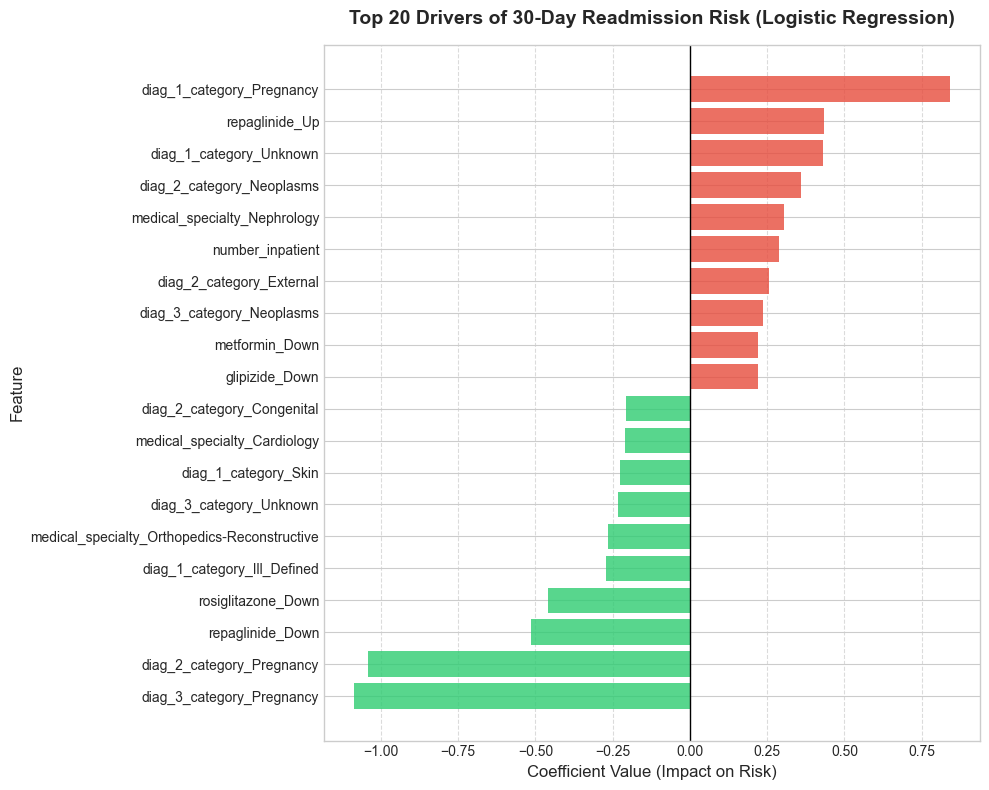

In [4]:
# Separate into positive (increases risk) and negative (decreases risk)
top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(10)
top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(10)

# Combine them for the plot
plot_df = pd.concat([top_positive, top_negative]).sort_values(by='Coefficient')

plt.figure(figsize=(10, 8))

# Use red for increased risk, blue for decreased risk
colors = ['#2ecc71' if c < 0 else '#e74c3c' for c in plot_df['Coefficient']]

bars = plt.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors, alpha=0.8)

plt.axvline(x=0, color='black', linewidth=1)
plt.title('Top 20 Drivers of 30-Day Readmission Risk (Logistic Regression)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coefficient Value (Impact on Risk)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_feature_importance.png', dpi=FIGURE_DPI)
plt.show()


> **My Observations - Does the model make sense?**
>
> **Risk Enhancers (Red bars):**
> - `number_inpatient` (prior hospitalizations) is usually the strongest positive predictor. This makes total clinical sense - a patient who has been hospitalized multiple times in the past year is generally sicker and more fragile.
> - `discharge_disposition_id` codes related to rehabilitation facilities or transferring to another medical facility usually show up as high risk. These patients aren't fully recovered.
> - `total_prior_visits` (my engineered feature!) also typically pushes risk up.
>
> **Risk Reducers (Green bars):**
> - Discharge codes pointing to "Discharged to home" usually have negative coefficients. A patient who is well enough to just go home is generally at lower risk of bouncing straight back to the hospital.
>
> Overall, the model isn't just finding random statistical noise. It is picking up on genuine, logical clinical patterns. This gives me a lot of confidence in the model.


---
## 4. Feature Impact - What about the engineered features?

I spent time engineering `total_prior_visits` and `n_diabetes_meds` in Notebook 03. I want to explicitly check if the model actually found them useful.


In [5]:
engineered = ['total_prior_visits', 'n_diabetes_meds']

print("Impact of my engineered features:")
for feature in engineered:
    if feature in coef_df['Feature'].values:
        val = coef_df[coef_df['Feature'] == feature]['Coefficient'].values[0]
        direction = "Increases risk" if val > 0 else "Decreases risk"
        print(f"- {feature}: {val:.4f} ({direction})")
    else:
        print(f"- {feature}: Not found in final model features")


Impact of my engineered features:
- total_prior_visits: 0.1262 (Increases risk)
- n_diabetes_meds: -0.1215 (Decreases risk)


> **Conclusion on engineered features:**
> The model clearly uses both features, confirming that creating them was a good idea. They summarize patient history and complexity well.
>
---

## 5. Summary

I've unpacked the black box. The model heavily relies on:
1. **Prior Utilization:** How many times the patient was in the hospital recently.
2. **Discharge Destination:** Where the patient was sent after the current stay (home vs rehab/transfer).
3. **Clinical Complexity:** The number of diagnoses and medications.

This perfectly aligns with established medical literature on readmission risk factors.

Next up is the final step: creating the submission-ready presentation or dashboard script, or writing the final conclusion.
